In [1]:
import pandas as pd
import numpy as np

csv_filename = "data/data.csv"

# provera da ispravno pravimo data.csv fajl od polaznih fajlova koji predstavljaju dataset kako bi olaksali upotrebu i manipulaciju dataset-om
df = pd.read_csv(csv_filename)
print(df.head())

print("Provera broja NaN/null vrednosti:")
print(df.isna().sum().sum())

print("Provera broja inf vrednosti za numericke atribute:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("Provera broja redova i kolona: ")
print(df.shape)

print("Provera broja subjekata i balansiranosti podataka po subjektu: ")
print(df[["subject_id", "target"]].value_counts())

print("Provera balansiranosti klasa: ")
print(df["target"].value_counts())

print("Provera broja atributa po vrsti merenja:")
print(f"ECG: {df.columns.str.startswith("ECG").sum()}")
print(f"TIB: {df.columns.str.startswith("IT").sum()}")
print(f"EDA arm: {df.columns.str.startswith("EDA_Arm").sum()}")
print(f"EDA hand: {df.columns.str.startswith("EDA_Hand").sum()}")

   subject_id  ECG_original_mean  ECG_original_std  ECG_original_trimmean25  \
0           1          -0.004125          0.254095                 0.001426   
1           1           0.031029          0.193761                 0.012918   
2           1           0.015678          0.182336                -0.003028   
3           1           0.014525          0.176636                -0.006161   
4           1           0.010349          0.179248                -0.008526   

   ECG_original_median  ECG_original_skewness  ECG_original_kurtosis  \
0             -0.01037              -0.538509                5.95534   
1             -0.00237               0.781415                5.18794   
2             -0.02337               0.881194                5.66530   
3             -0.02737               1.024900                6.10968   
4             -0.02737               0.935697                5.83902   

   ECG_original_max  ECG_original_min  ECG_original_prctile25  ...  \
0           1.04063   

In [2]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df.drop(columns=["subject_id", "target"])
y = df["target"]
groups = df["subject_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Dimenzije trening skupa: ", X_train.shape, y_train.shape)
print("Dimenzije test skupa: ", X_test.shape, y_test.shape)

print("Provera da se subjekti ne preklapaju izmedju trening i test skupa: ")
print("Broj zajednickih subjekata: ", len(set(groups_train) & set(groups_test)))
print("Broj subjekata u trening skupu: ", groups_train.nunique())
print("Broj subjekata u test skupu: ", groups_test.nunique())
print("Subjekti u test skupu: ", sorted(set(groups_test)))

print("Provera da su svi redovi svakog subjekta ostali na istoj strani podele: ")
print(all(groups_train.value_counts() == 112) and all(groups_test.value_counts() == 112))

print("Provera balansiranosti klasa u trening skupu: ")
print(y_train.value_counts(normalize=True).sort_index())
print("Provera balansiranosti klasa u test skupu: ")
print(y_test.value_counts(normalize=True).sort_index())

# Normalizuje podatke grupisane po subjektu kako bi izbacili sum subjekta i prepoznavali aktivnosti samo na osnovu apsolutnih vrednosti atributa (ublazili uticaj subjekta)
# Mozemo da odmah izvrsimo i normalizaciju test podataka, zato sto je ova standardizacija po subjektu, i gleda samo redove grupisane po subjektu, pa nema curenja informacija iz testa
# koje mogu da dovedu do preprilagodjavanja modela
# Zamka: ako je atribut kod nekog ispitanika konstantan kroz svih 112 njegovih merenja, njegova standardna devijacija je 0,
# pa deljenje daje 0/0 = NaN, iako u polaznim podacima nema nijedne nedostajuce vrednosti.
# Takvih (ispitanik, atribut) parova ima 211 u trening i 48 u test skupu, sto pravi desetine hiljada NaN vrednosti.
# Resenje nije izbacivanje tih redova ili kolona, nego vrednost 0: ako su sve vrednosti jednake proseku, onda je odstupanje
# od sopstvenog proseka bas nula. Zato standardnu devijaciju 0 zamenjujemo jedinicom, pa je (v - v.mean()) / 1 = 0.
def normalize_per_subject(frame, subject_groups):
    grouped = frame.groupby(subject_groups)
    return (frame - grouped.transform("mean")) / grouped.transform("std").replace(0.0, 1.0)


X_train_normalized = normalize_per_subject(X_train, groups_train)
X_test_normalized = normalize_per_subject(X_test, groups_test)

print("Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: ")
print("  trening skup: ", int((X_train.groupby(groups_train).std() == 0).to_numpy().sum()))
print("  test skup: ", int((X_test.groupby(groups_test).std() == 0).to_numpy().sum()))

print("Provera da posle normalizacije nema NaN vrednosti: ")
print("  trening skup: ", int(X_train_normalized.isna().sum().sum()))
print("  test skup: ", int(X_test_normalized.isna().sum().sum()))

print("Provera da posle normalizacije nema inf vrednosti: ")
print("  trening skup: ", int(np.isinf(X_train_normalized.to_numpy()).sum()))
print("  test skup: ", int(np.isinf(X_test_normalized.to_numpy()).sum()))

print("Provera da su dimenzije ostale iste: ")
print("  trening skup: ", X_train.shape, "->", X_train_normalized.shape)
print("  test skup: ", X_test.shape, "->", X_test_normalized.shape)

# posle normalizacije svaki ispitanik ima prosek 0 po svakom atributu (kod konstantnih atributa je ceo niz nula)
print("Najveci apsolutni prosek po (ispitanik, atribut) posle normalizacije (ocekujemo ~0): ",
      float(X_train_normalized.groupby(groups_train).mean().abs().to_numpy().max()))

all_zero_columns = (X_train_normalized == 0).all()
print("Atributi koji su posle normalizacije svuda nula (konstantni kod svih ispitanika): ",
      list(all_zero_columns.index[all_zero_columns]))


Dimenzije trening skupa:  (3584, 533) (3584,)
Dimenzije test skupa:  (896, 533) (896,)
Provera da se subjekti ne preklapaju izmedju trening i test skupa: 
Broj zajednickih subjekata:  0
Broj subjekata u trening skupu:  32
Broj subjekata u test skupu:  8
Subjekti u test skupu:  [5, 13, 16, 17, 20, 27, 28, 38]
Provera da su svi redovi svakog subjekta ostali na istoj strani podele: 
True
Provera balansiranosti klasa u trening skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Provera balansiranosti klasa u test skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: 
  trening skup:  211
  test skup:  48
Provera da posle normalizacije nema NaN vrednosti: 
  trening skup:  0
  test skup:  0
Provera da posle normalizacije nema inf vrednosti: 
  trening skup:  0
  test skup:  0
Provera da su dimenzije ostale iste: 
  trening sk

In [3]:
# Sada vrsimo redukciju atributa iz vise koraka: eliminisanje po varijansi, grupisanje elemenata u klastere po Spermanovoj korelaciji (robusnija na dugacke repove i ekstremne vrednosti u raspodelama
# atributa i bolje hvata nelinearne veze), racunanje mutual information svih atributa, biranje predstavnika iz svakog klastera sa najvecim mutual information (uklanjamo redudantne atribute) i na kraju
# izbor top k atributa po mutual information (to je nasa mera vaznosti atributa, koliko dobro se klase razdvajaju na osnovu vrednosti atributa)
# Normalizaciju vrsimo pre koraka redukcije atributa. Ona ne utice na mutual information. Mutual information i Spermanova korelacija su robusne na monotone transformacije (kakva je standardizacija po
# z-score). Doduse nije robusna na lokalnu standardizaciju po subjektu, koja globalno nije monotona transformacija za atribute, ali je to u redu, jer time i dobijamo odgovarajuce grupisanje u klastere na
# osnovu korelacija po vrednostima atributa, a bez da neki atributi ne budu u istom klasteru jer je odredjena podgrupa subjekata povukla raspodelu vrednosti tog atributa u drugu stranu tako da bude
# pridruzena nekom drugom klasteru kojem zapravo manje odgovara i manje ima smisla. Sto se tice normalizacije pre uklanjanja po varijansi, to ima smisla jer bi inace moglo da se desi da neki atributi imaju
# skoro konstantne vrednosti tokom vise redova, ali zbog ispitanika koji zbog svojih specificnosti povuku vrednosti nekog atributa to ne bude slucaj, al je ustvari rec samo o blago pomerenoj raspodeli, ne
# i nuzno razlicitoj raspodeli

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.feature_selection import mutual_info_classif

# iako atributi mogu i verovatno jesu na razlicitim skalama (merenja u razlicitim redovima velicine) zbog cega provera da li su gotovo konstante vrednosti svih
# redova preko apsolutne vrednosti za varijansu moze biti pogresna (ako su sve vrednosti malog reda velicine), ali ovoliko mali broj mozemo smatrati gotovo nula u
# bilo kom redu velicine
VARIANCE_THRESHOLD = 1e-12
CORR_THRESHOLD = 0.8  # granica preko koje smatramo da su dva atributa redundantna
TOP_K = 15

# --- Korak 1: izbacujemo atribute cija je varijansa bliska nuli ---
# takvi atributi su prakticno konstantni kroz sva merenja, pa ni ne mogu da razdvoje redove po klasama
variances = X_train_normalized.var()
low_variance_mask = variances.abs() < VARIANCE_THRESHOLD
X_train_step1 = X_train_normalized.loc[:, ~low_variance_mask]

print("Korak 1 - filtriranje po varijansi:")
print("Broj atributa pre filtriranja: ", X_train_normalized.shape[1])
print("Broj izbacenih atributa: ", int(low_variance_mask.sum()))
print("Izbaceni atributi: ", list(variances.index[low_variance_mask]))
print("Broj atributa posle filtriranja: ", X_train_step1.shape[1])

# --- Korak 2: uzajamna informacija (mutual information) izmedju svakog atributa i ciljne klase ---
# za razliku od korelacije sa ciljem, MI hvata i nelinearne veze, a ciljna klasa je kategoricka pa nam korelacija ovde ionako ne bi valjala
mi_scores = pd.Series(
    mutual_info_classif(X_train_step1, y_train, random_state=RANDOM_STATE),
    index=X_train_step1.columns,
)

print("Korak 2 - uzajamna informacija:")
print("Najboljih 10 atributa po MI: ")
print(mi_scores.sort_values(ascending=False).head(10))

# --- Korak 3: grupisemo redundantne atribute hijerarhijskim klasterovanjem po korelaciji ---
# veliki broj atributa opisuje istu stvar na malo drugaciji nacin (npr. ECG_hrv_mean, ECG_hrv_median i ECG_hrv_trimmean25 su sve mere centra iste raspodele),
# pa nose skoro istu informaciju i samo vestacki uvecavaju dimenziju.
# Koristimo Spearman-ovu korelaciju jer je otporna na ekstremne vrednosti (a ovde ima atributa reda 1e8) i hvata sve monotone, ne samo linearne veze.
# Rastojanje definisemo kao 1 - |korelacija|, pa jako korelisani atributi imaju malo rastojanje bez obzira na znak korelacije.
# Average linkage je prikladan za ovakvu matricu rastojanja, dok ward metod nije jer on zahteva euklidsko rastojanje.
corr_matrix = X_train_step1.corr(method="spearman").fillna(0.0)
abs_corr = corr_matrix.abs()
distance_matrix = 1.0 - abs_corr.to_numpy()
# numericka simetrizacija - squareform zahteva tacno simetricnu matricu sa nulama na dijagonali
distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
np.fill_diagonal(distance_matrix, 0.0)
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)

linkage_matrix = linkage(squareform(distance_matrix, checks=False), method="average")
clusters = pd.Series(
    fcluster(linkage_matrix, t=1.0 - CORR_THRESHOLD, criterion="distance"),
    index=X_train_step1.columns,
)

# iz svakog klastera uzimamo jednog predstavnika - atribut sa najvecom uzajamnom informacijom
representatives = list(mi_scores.groupby(clusters).idxmax())

print("Korak 3 - klasterovanje korelisanih atributa:")
print("Broj klastera (odnosno broj preostalih atributa): ", clusters.nunique())
print("Broj atributa koji su bili u klasteru sa bar jos jednim atributom: ", int((clusters.map(clusters.value_counts()) > 1).sum()))
print("Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: ")
for cluster_id, size in clusters.value_counts().head(3).items():
    members = list(clusters.index[clusters == cluster_id])
    print(f"  klaster {cluster_id}, velicina {size}, predstavnik: {mi_scores.loc[members].idxmax()}")
    print(f"    clanovi: {members[:5]}{' ...' if len(members) > 5 else ''}")

# --- Korak 4: od predstavnika klastera uzimamo TOP_K najboljih po uzajamnoj informaciji ---
# Vazno: klasterovanje samo po sebi NE garantuje da predstavnici razlicitih klastera nisu medjusobno redundantni.
# Average linkage spaja klastere po prosecnom rastojanju, pa pojedinacan par atributa iz dva razlicita klastera
# moze da ostane iznad praga korelacije (kod nas su to bili IT_LF_max i IT_RF_max sa |korelacijom| = 0.84).
# Zato predstavnike obilazimo redom po opadajucem MI i zadrzavamo kandidata samo ako nije jako korelisan
# ni sa jednim vec zadrzanim atributom. Tako invarijanta "u konacnom skupu nema para sa |korelacijom| >= CORR_THRESHOLD"
# vazi po konstrukciji, a ne na osnovu srece pri klasterovanju.
ordered_representatives = mi_scores.loc[representatives].sort_values(ascending=False)

selected_features = []
rejected_as_redundant = []
for candidate in ordered_representatives.index:
    if len(selected_features) == TOP_K:
        break
    redundant_with = [kept for kept in selected_features if abs_corr.loc[candidate, kept] >= CORR_THRESHOLD]
    if redundant_with:
        rejected_as_redundant.append((candidate, redundant_with[0], round(float(abs_corr.loc[candidate, redundant_with[0]]), 4)))
    else:
        selected_features.append(candidate)

X_train_reduced = X_train_normalized[selected_features]
X_test_reduced = X_test_normalized[selected_features]

print("Korak 4 - izbor najboljih", TOP_K, "atributa: ")
print(mi_scores.loc[selected_features])
print("Predstavnici odbaceni jer su redundantni sa vec izabranim atributom: ")
for candidate, kept, value in rejected_as_redundant:
    print(f"  {candidate} (redundantan sa {kept}, |korelacija| = {value})")

print("Dimenzije trening skupa posle redukcije: ", X_train_reduced.shape)
print("Dimenzije test skupa posle redukcije: ", X_test_reduced.shape)

print("Provera da su izabrani atributi zaista podskup polaznih atributa: ")
print(set(selected_features).issubset(set(X.columns)))

print("Provera koliko je svaka vrsta merenja zastupljena medju izabranim atributima: ")
selected_index = pd.Index(selected_features)
for signal in ["ECG", "IT", "EDA_Arm", "EDA_Hand"]:
    print(f"  {signal}: {int(selected_index.str.startswith(signal).sum())}")

# provera invarijante iz koraka 4 - medju izabranim atributima ne sme da postoji par sa |korelacijom| >= CORR_THRESHOLD
selected_corr = X_train_reduced.corr(method="spearman").abs().to_numpy(copy=True)
np.fill_diagonal(selected_corr, 0.0)
print("Najveca apsolutna korelacija izmedju izabranih atributa: ", round(float(selected_corr.max()), 4))
print("Provera da nema redundantnih parova medju izabranim atributima: ", bool(selected_corr.max() < CORR_THRESHOLD))

Korak 1 - filtriranje po varijansi:
Broj atributa pre filtriranja:  533
Broj izbacenih atributa:  6
Izbaceni atributi:  ['ECG_p_VFL_kurtosis', 'ECG_p_LF_kurtosis', 'IT_VLF_kurtosis', 'IT_LF_kurtosis.1', 'EDA_Arm_amp_scr', 'EDA_Hand_amp_scr']
Broj atributa posle filtriranja:  527
Korak 2 - uzajamna informacija:
Najboljih 10 atributa po MI: 
IT_BRV_baseline         1.133970
IT_VLF_baseline         0.991185
IT_p_Total_baseline     0.970467
IT_LF_baseline.1        0.957114
IT_PSD_baseline         0.922431
IT_MF_baseline          0.921851
ECG_amplitude_RR_min    0.875268
IT_Original_max         0.866292
IT_LF_max               0.860384
IT_RF_max               0.854057
dtype: float64
Korak 3 - klasterovanje korelisanih atributa:
Broj klastera (odnosno broj preostalih atributa):  112
Broj atributa koji su bili u klasteru sa bar jos jednim atributom:  462
Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: 
  klaster 47, velicina 80, predstavnik: IT_MF_HF
    clanovi: ['IT_B

In [4]:
# Gornju redukciju atributa sada pakujemo u sklearn transformator, da bi mogla da se koristi unutar Pipeline-a isto kao PCA ili LDA.
# Zasto je to neophodno, a ne samo kozmeticko: nasa redukcija je NADGLEDANA (mutual information gleda y, tj. ciljnu klasu), pa skup od 15 atributa
# koji smo gore dobili zavisi od celog trening skupa. Ako bismo taj fiksni skup atributa prosledili u GridSearchCV, svaki validacioni podskup bi
# bio ocenjen atributima koji su birani i na osnovu njegovih redova - to je curenje informacija i precenjena ocena tacnosti modela.
# Kada je redukcija transformator u Pipeline-u, GridSearchCV je poziva iznova na svakom trening delu podele (fit), a validacioni deo samo
# transformise (transform), pa izbor atributa nikada ne vidi redove na kojima se model ocenjuje.
# Konvencija sklearn-a koju pratimo:
#   - fit(X, y) uci sta treba da se zapamti i vraca self, transform(X) samo primenjuje naucen izbor
#   - sve sto je nauceno stoji u atributima sa donjom crtom na kraju (selected_features_, mi_scores_, ...)
#   - __init__ ne radi nikakav posao; posto po dogovoru ovaj metod nema hiperparametre, on i ne postoji, pa je get_params() prazan recnik,
#     a clone() (koji GridSearchCV interno koristi za svaku kombinaciju parametara) radi bez ijedne dodatne linije.
#     Ako bismo kasnije zeleli da trazimo najbolje CORR_THRESHOLD i TOP_K, oni bi postali argumenti __init__-a i mogli bi da udju u mrezu pretrage.
# Normalizacija po subjektu namerno ostaje van Pipeline-a: njoj treba subject_id (grupe), a ne samo X, i kao sto je gore objasnjeno ona ne
# donosi curenje informacija, pa moze da se uradi jednom, pre podele na foldove.

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.utils.validation import check_is_fitted


class InterpretableFeatureReducer(BaseEstimator, TransformerMixin):
    """Redukcija atributa u 4 koraka (varijansa -> MI -> klasteri po korelaciji -> pohlepni izbor TOP_K),
    upakovana kao sklearn transformator. Za razliku od PCA i LDA, izlaz je pravi podskup polaznih kolona,
    pa rezultat ostaje interpretabilan kao "bas ovo merenje sa ovog senzora razdvaja aktivnosti"."""

    def _as_frame(self, X):
        # radimo sa DataFrame-om zbog imena kolona, ali dozvoljavamo i numpy niz (npr. ako je pre nas u Pipeline-u neki drugi transformator)
        if isinstance(X, pd.DataFrame):
            return X
        values = np.asarray(X)
        return pd.DataFrame(values, columns=[f"x{i}" for i in range(values.shape[1])])

    def fit(self, X, y):
        frame = self._as_frame(X)
        y = np.asarray(y).ravel()

        # --- Korak 1: izbacujemo atribute cija je varijansa bliska nuli ---
        variances = frame.var()
        keep_mask = variances.abs() >= VARIANCE_THRESHOLD
        frame_step1 = frame.loc[:, keep_mask]

        # --- Korak 2: uzajamna informacija svakog preostalog atributa sa ciljnom klasom ---
        mi_scores = pd.Series(
            mutual_info_classif(frame_step1, y, random_state=RANDOM_STATE),
            index=frame_step1.columns,
        )

        # --- Korak 3: hijerarhijsko klasterovanje po Spearman-ovoj korelaciji, predstavnik klastera je atribut sa najvecim MI ---
        abs_corr = frame_step1.corr(method="spearman").fillna(0.0).abs()
        distance_matrix = 1.0 - abs_corr.to_numpy()
        distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
        np.fill_diagonal(distance_matrix, 0.0)
        distance_matrix = np.clip(distance_matrix, 0.0, 1.0)
        linkage_matrix = linkage(squareform(distance_matrix, checks=False), method="average")
        clusters = pd.Series(
            fcluster(linkage_matrix, t=1.0 - CORR_THRESHOLD, criterion="distance"),
            index=frame_step1.columns,
        )
        representatives = list(mi_scores.groupby(clusters).idxmax())

        # --- Korak 4: pohlepni izbor TOP_K predstavnika bez medjusobno redundantnih parova ---
        selected_features = []
        for candidate in mi_scores.loc[representatives].sort_values(ascending=False).index:
            if len(selected_features) == TOP_K:
                break
            if not any(abs_corr.loc[candidate, kept] >= CORR_THRESHOLD for kept in selected_features):
                selected_features.append(candidate)

        self.n_features_in_ = frame.shape[1]
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = np.asarray(frame.columns, dtype=object)
        self.mi_scores_ = mi_scores
        self.clusters_ = clusters
        self.selected_features_ = selected_features
        # pamtimo i redne brojeve kolona, da transform radi i kada ulaz nije DataFrame
        self.selected_indices_ = np.array([frame.columns.get_loc(name) for name in selected_features])
        return self

    def transform(self, X):
        check_is_fitted(self, "selected_indices_")
        frame = self._as_frame(X)
        if frame.shape[1] != self.n_features_in_:
            raise ValueError(f"ocekivano {self.n_features_in_} atributa, a dobijeno {frame.shape[1]}")
        reduced = frame.iloc[:, self.selected_indices_]
        return reduced if isinstance(X, pd.DataFrame) else reduced.to_numpy()

    def get_feature_names_out(self, input_features=None):
        # da bi Pipeline mogao da prosledi imena kolona dalje (npr. za znacaj atributa u modelu)
        check_is_fitted(self, "selected_features_")
        return np.asarray(self.selected_features_, dtype=object)

    def __sklearn_tags__(self):
        # oznaka da je metod nadgledan, tj. da fit bez y nema smisla
        tags = super().__sklearn_tags__()
        tags.target_tags.required = True
        return tags


# --- Provera da transformator daje potpuno isti rezultat kao kod iz prethodne celije ---
feature_reducer = InterpretableFeatureReducer()
X_train_reduced_pipe = feature_reducer.fit_transform(X_train_normalized, y_train)
X_test_reduced_pipe = feature_reducer.transform(X_test_normalized)

print("Provera da transformator bira iste atribute kao rucno napisan kod: ")
print("  izabrani atributi: ", feature_reducer.selected_features_)
print("  isti skup i isti redosled kao selected_features: ", feature_reducer.selected_features_ == selected_features)
print("  iste vrednosti u trening skupu: ", bool(np.allclose(X_train_reduced_pipe.to_numpy(), X_train_reduced.to_numpy())))
print("  iste vrednosti u test skupu: ", bool(np.allclose(X_test_reduced_pipe.to_numpy(), X_test_reduced.to_numpy())))
print("  dimenzije: ", X_train_reduced_pipe.shape, X_test_reduced_pipe.shape)

print("Provera sklearn konvencija: ")
print("  get_params (ocekujemo prazno, jer nema hiperparametara): ", feature_reducer.get_params())
print("  clone pravi novu, nefitovanu kopiju: ", clone(feature_reducer))
print("  get_feature_names_out: ", list(feature_reducer.get_feature_names_out()[:3]), "...")
print("  radi i sa numpy ulazom: ", InterpretableFeatureReducer().fit_transform(X_train_normalized.to_numpy(), y_train.to_numpy()).shape)

Provera da transformator bira iste atribute kao rucno napisan kod: 
  izabrani atributi:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
  isti skup i isti redosled kao selected_features:  True
  iste vrednosti u trening skupu:  True
  iste vrednosti u test skupu:  True
  dimenzije:  (3584, 15) (896, 15)
Provera sklearn konvencija: 
  get_params (ocekujemo prazno, jer nema hiperparametara):  {}
  clone pravi novu, nefitovanu kopiju:  InterpretableFeatureReducer()
  get_feature_names_out:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min'] ...
  radi i sa numpy ulazom:  (3584, 15)


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_feature_reduction_pipe = Pipeline([
    ("feature_reduction", InterpretableFeatureReducer()),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1)),
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_feature_reduction = GridSearchCV(knn_feature_reduction_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_feature_reduction.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za KNN nad intepretabilnom, redukovanom skupu atributa: ")
print(" najbolji parametri: ", knn_gs_feature_reduction.best_params_)
print(" atributi izabrani u finalnom modelu: ", list(knn_gs_feature_reduction.best_estimator_.named_steps["feature_reduction"].get_feature_names_out()))
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_feature_reduction.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_feature_reduction.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs_feature_reduction.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_feature_reduction.predict(X_test_normalized)))

Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearch za KNN nad intepretabilnom, redukovanom skupu atributa: 
 najbolji parametri:  {'knn__n_neighbors': 91, 'knn__p': 1, 'knn__weights': 'distance'}
 atributi izabrani u finalnom modelu:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
 najbolja tacnost na unakrsnoj validaciji:  0.8208705357142857
 tacnost finalnog modela na test skupu:  0.8080357142857143
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      185       18       21        0
2-emoc.        0      175       49        0
3-ment.       29       55      140        0
4-fizi.        0        0        0      224
 dodatne statistike klasifikacije: 
              precision    recall  f1-sco

In [10]:
from sklearn.decomposition import PCA

knn_pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "pca__whiten": [True, False],
    "pca__n_components": [0.9, 0.95],
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_pca = GridSearchCV(knn_pca_pipeline, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_pca.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za KNN nad PCA komponentama:")
print(" najbolji parametri: ", knn_gs_pca.best_params_)
print(" broj PCA komponenti: ", knn_gs_pca.best_estimator_.named_steps["pca"].n_components_)
print(" ukupna objasnjenja varijansa: ", knn_gs_pca.best_estimator_.named_steps["pca"].explained_variance_ratio_.sum())
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_pca.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_pca.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs_pca.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_pca.predict(X_test_normalized)))

Fitting 4 folds for each of 272 candidates, totalling 1088 fits
GridSearchCV za KNN nad PCA komponentama:
 najbolji parametri:  {'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance', 'pca__n_components': 0.9, 'pca__whiten': False}
 broj PCA komponenti:  44
 ukupna objasnjenja varijansa:  0.9004374857767707
 najbolja tacnost na unakrsnoj validaciji:  0.7653459821428572
 tacnost finalnog modela na test skupu:  0.7678571428571429
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      164       20       38        2
2-emoc.        0      163       60        1
3-ment.        0       78      145        1
4-fizi.        0        0        8      216
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.73      0.85       224
           2       0.62      0.73      0.67       224
           3       0.58      0.65      0.61       224
           4       0.98      0.96      0.97       224

    accura

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

knn_lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA(solver="svd", n_components=3)),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_lda = GridSearchCV(knn_lda_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_lda.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za KNN nad LDA komponentama:")
print(" najbolji parametri: ", knn_gs_lda.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_lda.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_lda.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs_lda.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_lda.predict(X_test_normalized)))

Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearchCV za KNN nad LDA komponentama:
 najbolji parametri:  {'knn__n_neighbors': 19, 'knn__p': 1, 'knn__weights': 'distance'}
 najbolja tacnost na unakrsnoj validaciji:  0.7606026785714286
 tacnost finalnog modela na test skupu:  0.8024553571428571
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      193       19       12        0
2-emoc.        0      125       99        0
3-ment.        3       39      182        0
4-fizi.        0        0        5      219
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.98      0.86      0.92       224
           2       0.68      0.56      0.61       224
           3       0.61      0.81      0.70       224
           4       1.00      0.98      0.99       224

    accuracy                           0.80       896
   macro avg       0.82      0.80      0.80       896
weighted avg       0.82      

In [13]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs = GridSearchCV(knn_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za KNN nad svim atributima:")
print(" najbolji parametri: ", knn_gs.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearchCV za KNN nad svim atributima:
 najbolji parametri:  {'knn__n_neighbors': 31, 'knn__p': 1, 'knn__weights': 'uniform'}
 najbolja tacnost na unakrsnoj validaciji:  0.7709263392857143
 tacnost finalnog modela na test skupu:  0.7645089285714286
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      145       46       32        1
2-emoc.        0      142       82        0
3-ment.        0       40      183        1
4-fizi.        0        1        8      215
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.65      0.79       224
           2       0.62      0.63      0.63       224
           3       0.60      0.82      0.69       224
           4       0.99      0.96      0.98       224

    accuracy                           0.76       896
   macro avg       0.80      0.76      0.77       896
weighted avg       0.80      0.

# Poredjenje KNN modela nad cetiri skupa atributa

Sva cetiri modela su ocenjena pod istim uslovima, pa je poredjenje posteno:

- ista podela na trening i test po subjektu (`GroupShuffleSplit`, 32 subjekta / 3584 reda za trening, 8 subjekata / 896 redova za test, po 224 reda svake klase),
- ista normalizacija po subjektu pre svega ostalog,
- ista unakrsna validacija `GroupKFold(n_splits=4)` po subjektu, dakle svaki fold ocenjuje model na 8 subjekata koje model nije video,
- ista mreza parametara za KNN (`n_neighbors`, `weights`, `p`), uz `StandardScaler` neposredno pre KNN-a, jer je KNN zasnovan na rastojanju,
- svaki korak redukcije (i nadgledani i nenadgledani) je unutar `Pipeline`-a, pa se iznova uci na trening delu svakog folda i nema curenja informacija.

## Zbirni rezultati

| Ulaz u KNN | Broj dimenzija | Najbolji parametri | Tacnost (CV) | Tacnost (test) | Macro F1 (test) |
|---|---|---|---|---|---|
| Interpretabilna redukcija | 15 | k=91, p=1 (Menhetn), distance | **0.8209** | **0.8080** | **0.81** |
| PCA | 44 (90.04% varijanse) | k=15, p=2, distance, whiten=False | 0.7653 | 0.7679 | 0.78 |
| LDA | 3 | k=19, p=1, distance | 0.7606 | 0.8025 | 0.80 |
| Svi atributi | 533 | k=31, p=1, uniform | 0.7709 | 0.7645 | 0.77 |

F1 po klasama na test skupu:

| Klasa | Interpretabilna (15) | PCA (44) | LDA (3) | Svi (533) |
|---|---|---|---|---|
| 1 - neutralna | 0.84 | 0.85 | **0.92** | 0.79 |
| 2 - emocionalna | **0.74** | 0.67 | 0.61 | 0.63 |
| 3 - mentalna | 0.65 | 0.61 | **0.70** | 0.69 |
| 4 - fizicka | **1.00** | 0.97 | 0.99 | 0.98 |

Raspodela gresaka na test skupu (896 redova):

| Model | Ukupno gresaka | emocionalna <-> mentalna | Udeo tog para u greskama | Tacnost na paru emoc.+ment. (448 redova) | Tacnost na neut.+fizickoj (448 redova) | Greske koje ukljucuju fizicku |
|---|---|---|---|---|---|---|
| Interpretabilna (15) | **172** | 104 | 60.5% | 0.703 | 0.913 | **0** |
| PCA (44) | 208 | 138 | 66.3% | 0.688 | 0.848 | 12 |
| LDA (3) | 177 | 138 | 78.0% | 0.685 | **0.920** | 5 |
| Svi (533) | 211 | 122 | 57.8% | **0.725** | 0.804 | 11 |

## Sta rezultati govore

### 1. Redukcija atributa pomaze, ali samo ako je nadgledana

Model nad svih 533 atributa je najlosiji (test 0.7645), iako ima na raspolaganju sve informacije koje imaju i ostali modeli. To je ocekivano ponasanje KNN-a u visokoj dimenziji: rastojanje se racuna preko svih atributa podjednako, a ogromna vecina od 533 atributa je ili redundantna (462 atributa je zavrsilo u klasteru sa bar jos jednim atributom) ili slabo povezana sa aktivnoscu. Nekoliko informativnih atributa se tako utopi u sumu ostalih, pa "najblizi susedi" prestaju da budu i najslicniji po aktivnosti.

Redukcija na 15 interpretabilnih atributa - dakle na 2.8% polazne dimenzije - daje najbolji rezultat i po unakrsnoj validaciji (0.8209 naspram 0.7709) i na test skupu (0.8080 naspram 0.7645). Odbacivanje 518 atributa nije izgubilo informaciju, nego sum.

### 2. PCA jedva popravlja pun skup atributa

PCA sa 44 komponente daje 0.7679 na testu, samo 0.003 vise od punog skupa - razlika koja je unutar suma na 8 test subjekata. Razlog je u tome sto PCA trazi pravce najvece varijanse, a varijansa nije isto sto i razdvojivost klasa: komponente su gradjene bez ijednog pogleda na ciljnu klasu. Zato 44 komponente i dalje nose veliki deo iste one strukture koja je smetala i punom skupu.

Dva detalja iz pretrage to potvrdjuju: pobedili su `n_components=0.9` (a ne 0.95) i `whiten=False`. Manje zadrzane varijanse je bolje, jer je rep komponenti sum; a `whiten=True` bi sve komponente izjednacio po varijansi i time podigao znacaj bas tih slabih pravaca, sto skodi.

### 3. LDA: tri dimenzije nose skoro sve sto i 533

LDA svodi podatke na svega 3 dimenzije (vise nije ni moguce, jer je maksimalan broj diskriminantnih pravaca za 4 klase jednak 3) i sa njima postize 0.8025 na testu - bolje od punog skupa i od PCA, uz 178 puta manju dimenziju. Razlika u odnosu na PCA je ocekivana: LDA je nadgledana, pravce gradi bas tako da maksimizuje odnos razdvojenosti klasa i rasipanja unutar klasa.

Vredi primetiti i da je LDA sama po sebi, kao klasifikator, na istoj podeli davala 0.796 (videti `feature_reduction.ipynb`). KNN nad LDA prostorom daje 0.8025, dakle dobitak je zanemarljiv - u tom trodimenzionom prostoru granice izmedju klasa su vec skoro linearne, pa nelinearan model nema sta dodatno da iskoristi.

### 4. Sve greske se svode na par emocionalna / mentalna

Ovo je najvazniji nalaz i identican je kod sva cetiri modela: par emocionalna-mentalna nosi izmedju 57.8% i 78.0% svih gresaka, iako te dve klase cine samo polovinu test skupa. Fizicka aktivnost je, nasuprot tome, prakticno savrseno odvojiva - interpretabilni model je pogodio svih 224 reda i nijedan red nijedne druge klase nije proglasio fizickim, a i ostali modeli grese oko nje najvise 12 puta.

Time je potvrdjeno predvidjanje iz projekcione analize (PCA, t-SNE i LDA u `feature_reduction.ipynb`), gde su emocionalna i mentalna aktivnost u svakoj projekciji delile isti oblak tacaka, a fizicka je bila jasno odvojeno ostrvo. Sada to potvrdjuje i stvarni klasifikator, a ne samo slika.

Modeli se, medjutim, razlikuju po tome *kako* gube na tom paru:

- LDA je najlosija na emocionalnoj klasi (odziv 0.56): cak 99 od 224 emocionalna reda proglasi mentalnim. Trodimenzioni prostor je odlican za odvajanje neutralne i fizicke, ali treca LDA osa (koja jedina razdvaja emocionalnu od mentalne) nosi svega 2.63% razdvajanja, pa je klasifikator sistematski pomeren ka mentalnoj.
- Pun skup atributa je, zanimljivo, *najbolji* bas na tom paru (0.725), ali zato gubi neutralnu klasu (odziv 0.65, 46 neutralnih redova ode u emocionalnu) i zato je ukupno najlosiji.
- Interpretabilni skup je jedini koji je istovremeno dobar i na paru (0.703) i na lakom delu problema (0.913 na neutralnoj i fizickoj), i tu je izvor njegove prednosti.

### 5. Izabrane vrednosti hiperparametara

Kod svih modela pobedjuje relativno veliko `k` (15, 19, 31, 91), a nijednom malo `k` (1, 3, 5), sto znaci da su lokalna susedstva sumovita - najblizi sused cesto pripada istom subjektu, a ne istoj aktivnosti. Normalizacija po subjektu uklanja licni nivo svakog ispitanika, ali ne i njegovu kovarijansnu strukturu, sto je ista pojava koju t-SNE prikazuje kao sitne grupice po subjektu.

Najvece `k` (91, oko 2.5% trening skupa) pobedjuje bas kod skupa od 15 atributa: u niskoj dimenziji sa gustim, informativnim prostorom veliko susedstvo usrednjava sum bez opasnosti da "pokupi" tudju klasu. Menhetn rastojanje (`p=1`) pobedjuje u tri od cetiri slucaja, sto je uobicajeno u visedimenzionim prostorima, gde je manje osetljivo na pojedinacne ekstremne koordinate od euklidskog.

### 6. Odnos unakrsne validacije i test skupa

Kod tri modela su CV i test ocena bliske (razlika do 0.013), sto potvrdjuje da podela po subjektu i `GroupKFold` daju realnu procenu. Jedini izuzetak je LDA, gde je test ocena za 0.042 *bolja* od CV ocene. Objasnjenje je u velicini trening skupa: unutar unakrsne validacije LDA uci 533 koeficijenta na 24 subjekta (2688 redova) i osetno se preprilagodi, dok se finalni model uci na svih 32 subjekta (3584 reda) i bolje generalizuje. Zato je CV ocena za LDA pesimisticna.

Treba imati na umu i da test skup, iako ima 896 redova, sadrzi samo 8 nezavisnih subjekata, pa razlike reda 0.005-0.01 (npr. PCA naspram punog skupa, ili LDA naspram interpretabilnog modela) ne treba tumaciti kao stvarnu prednost. Razlika izmedju interpretabilnog skupa i preostala tri je jedina koja se istovremeno vidi i u unakrsnoj validaciji (0.8209 naspram 0.76-0.77, a ta ocena je usrednjena preko svih 32 trening subjekta) i na testu, pa je jedino nju mozemo smatrati stvarnom.

## Zakljucak

Najbolji model je **KNN (k=91, Menhetn rastojanje, distance tezine) nad 15 interpretabilnih atributa**, sa tacnoscu 0.8080 na nevidjenim subjektima. On je najbolji po svakom kriterijumu odjednom: najveca CV tacnost, najveca test tacnost, najveci macro F1, najmanji ukupan broj gresaka i jedini savrsen rezultat na fizickoj aktivnosti. Uz to je i najmanji (15 od 533 atributa) i jedini kod koga rezultat ostaje objasnjiv, jer su izlazne kolone prava merenja sa senzora, a ne linearne kombinacije.

Tacnost od 0.81 treba citati raslojeno: fizicka aktivnost se prepoznaje savrseno, neutralna vrlo dobro (F1 0.84), a par emocionalna-mentalna je granica koju nijedan od cetiri pristupa ne probija (oko 0.70). Buduci napredak, dakle, ne treba traziti u drugacijoj redukciji dimenzije - sve cetiri varijante se sudaraju sa istim zidom - nego ili u modelu koji ume da nauci da isti opseg vrednosti kod razlicitih subjekata znaci razlicitu klasu (sto smo videli kod bimodalnog `IT_BRV_baseline`), ili u atributima koji uopste nisu u ovom skupu podataka.

Takodje, u eksploraciji podataka smo videli da zapravo ne postoji ni jedan atribut ciji boxplot-ovi emocionalne i mentalne aktivnosti su u potpunosti razdvojeni, kao i da vec u ovih 15 atributa sadrzimo atribute koji imaju gotovo i najveci (najbolji) razmak izmedju te dve aktivnosti, odnosno najmanji presek.


In [23]:
X_train_top3 = X_train_normalized[["IT_BRV_baseline", "ECG_amplitude_RR_min", "EDA_Hand_Filt2_max"]]
X_test_top3 = X_test_normalized[["IT_BRV_baseline", "ECG_amplitude_RR_min", "EDA_Hand_Filt2_max"]]
print(knn_gs_feature_reduction.best_params_)

knn_top3_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_top3 = GridSearchCV(knn_top3_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_top3.fit(X_train_top3, y_train, groups=groups_train)

print("GridSearchCV za KNN nad top kombinacijom 3 interpretabilna atributa po razdvojenost boxplot-ova po klasama:")
print(" najbolji parametri: ", knn_gs_top3.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_top3.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_top3.best_estimator_.score(X_test_top3, y_test))

cm = confusion_matrix(y_test, knn_gs_top3.predict(X_test_top3))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_top3.predict(X_test_top3)))

{'knn__n_neighbors': 91, 'knn__p': 1, 'knn__weights': 'distance'}
Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearchCV za KNN nad top kombinacijom 3 interpretabilna atributa po razdvojenost boxplot-ova po klasama:
 najbolji parametri:  {'knn__n_neighbors': 51, 'knn__p': 1, 'knn__weights': 'distance'}
 najbolja tacnost na unakrsnoj validaciji:  0.8482142857142857
 tacnost finalnog modela na test skupu:  0.8024553571428571
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      181       25       15        3
2-emoc.        2      153       65        4
3-ment.       14       32      175        3
4-fizi.        0        0       14      210
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.92      0.81      0.86       224
           2       0.73      0.68      0.71       224
           3       0.65      0.78      0.71       224
           4       0.95      0.94      0.95       224

    a

Primecuje se da kombinacija tri atributa iz eksploracije podataka izvucena iz interpretabilnog redukovanog skupa atributa koja je jako dobro vizuelno razdvajala fizicku, neutralnu i mentalnu-emocionalnu klasu nosi najvise informacija o razdvajanju klasa od preostalih 12 atributa. Ono sto je primetno je da je model blago losiji, i zbog manje atributa, a verovatno i one podgrupe ispitanika koja postoji u trening podacima, a mozda nije prisutna u test podacima bas vezana za IT_BRV_baseline atribut koji najvise razdvaja klase (moze se videti iz boxplot-ova po klasama iz dela o eksploraciji podataka), se model vise prilagodi trening podacima u proseku, pa je preciznost u test podacima malo losija. Kada se pogleda i matrica konfuzije, vidi se da fizicka aktivnost sada nije 100% razdvojiva od ostalih klasa (sto znaci da preostalih 12 atributa uticu na bolje razdvajanje fizicke od ostalih, ili hvataju neophodne obrasce tako da su test podaci 100% razdvojivi po fizickoj klasi), ali takodje su i neutralna i emocionalna klasa lose razdvojive nego u slucaju svih 15 atributa. Ono sto je ovde zanimljivo je da je mentalna aktivnost sada bolje razdvojiva u odnosu na slucaj sa svih 15 atributa. To znaci da se u 3 dimenzije podaci koji prripadaju mentalnoj klasi bolje grupisu u klastere koji su udaljeniji od ostalih ili manje izmesani sa emocionalnom i neutralnom aktivnoscu. Svakako i dalje je prisutan problem, koji je sada vise obrazac, a to je da su emocionalna i mentalna aktivnost najteze za razdvajanje.

In [5]:
from sklearn.tree import DecisionTreeClassifier
from joblib import Memory
from feature_reduction.InterpretableFeatureReducer import InterpretableFeatureReducer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold


mem = Memory("./cache", verbose=0)
mem.clear(warn=False)

dtc_feature_reduction_pipe = Pipeline([
    ("feature_reduction", InterpretableFeatureReducer()),
    ("decision_tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=None)), # class_weight = None jer su klase balansirane
], memory=mem)

param_grid = {
    "decision_tree__criterion": ["gini", "entropy"],
    "decision_tree__max_depth": [2, 3, 4, 5, 6, 8, 10],
    "decision_tree__min_samples_leaf": [1, 5, 10, 20, 40],
    "decision_tree__ccp_alpha": [0.0, 0.001, 0.003, 0.01],
    "decision_tree__max_features": ["sqrt", None, 0.5],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
dtc_feature_reduction_gs = GridSearchCV(dtc_feature_reduction_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
dtc_feature_reduction_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za DecisionTree nad intepretabilnom, redukovanom skupu atributa: ")
print(" najbolji parametri: ", dtc_feature_reduction_gs.best_params_)
print(" atributi izabrani u finalnom modelu: ", list(dtc_feature_reduction_gs.best_estimator_.named_steps["feature_reduction"].get_feature_names_out()))
print(" najbolja tacnost na unakrsnoj validaciji: ", dtc_feature_reduction_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", dtc_feature_reduction_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, dtc_feature_reduction_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, dtc_feature_reduction_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 840 candidates, totalling 3360 fits
GridSearch za DecisionTree nad intepretabilnom, redukovanom skupu atributa: 
 najbolji parametri:  {'decision_tree__ccp_alpha': 0.003, 'decision_tree__criterion': 'gini', 'decision_tree__max_depth': 8, 'decision_tree__max_features': 0.5, 'decision_tree__min_samples_leaf': 20}
 atributi izabrani u finalnom modelu:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
 najbolja tacnost na unakrsnoj validaciji:  0.9296875
 tacnost finalnog modela na test skupu:  0.8928571428571429
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      181       17       26        0
2-emoc.        0      194       23        7
3-ment.       15        0      209        0
4-fizi.

In [11]:
tree = dtc_feature_reduction_gs.best_estimator_.named_steps['decision_tree']
print(f"dubina drveta: {tree.get_depth()}, broj listova: {tree.get_n_leaves()}")

i = dtc_feature_reduction_gs.best_index_
r = dtc_feature_reduction_gs.cv_results_
print(r['mean_test_score'][i], r['std_test_score'][i], r['mean_train_score'][i])
print([r[f'split{k}_test_score'][i] for k in range(4)])

dubina drveta: 8, broj listova: 18
0.9296875 0.020954222494998426 0.9556361607142857
[np.float64(0.9419642857142857), np.float64(0.8950892857142857), np.float64(0.9319196428571429), np.float64(0.9497767857142857)]


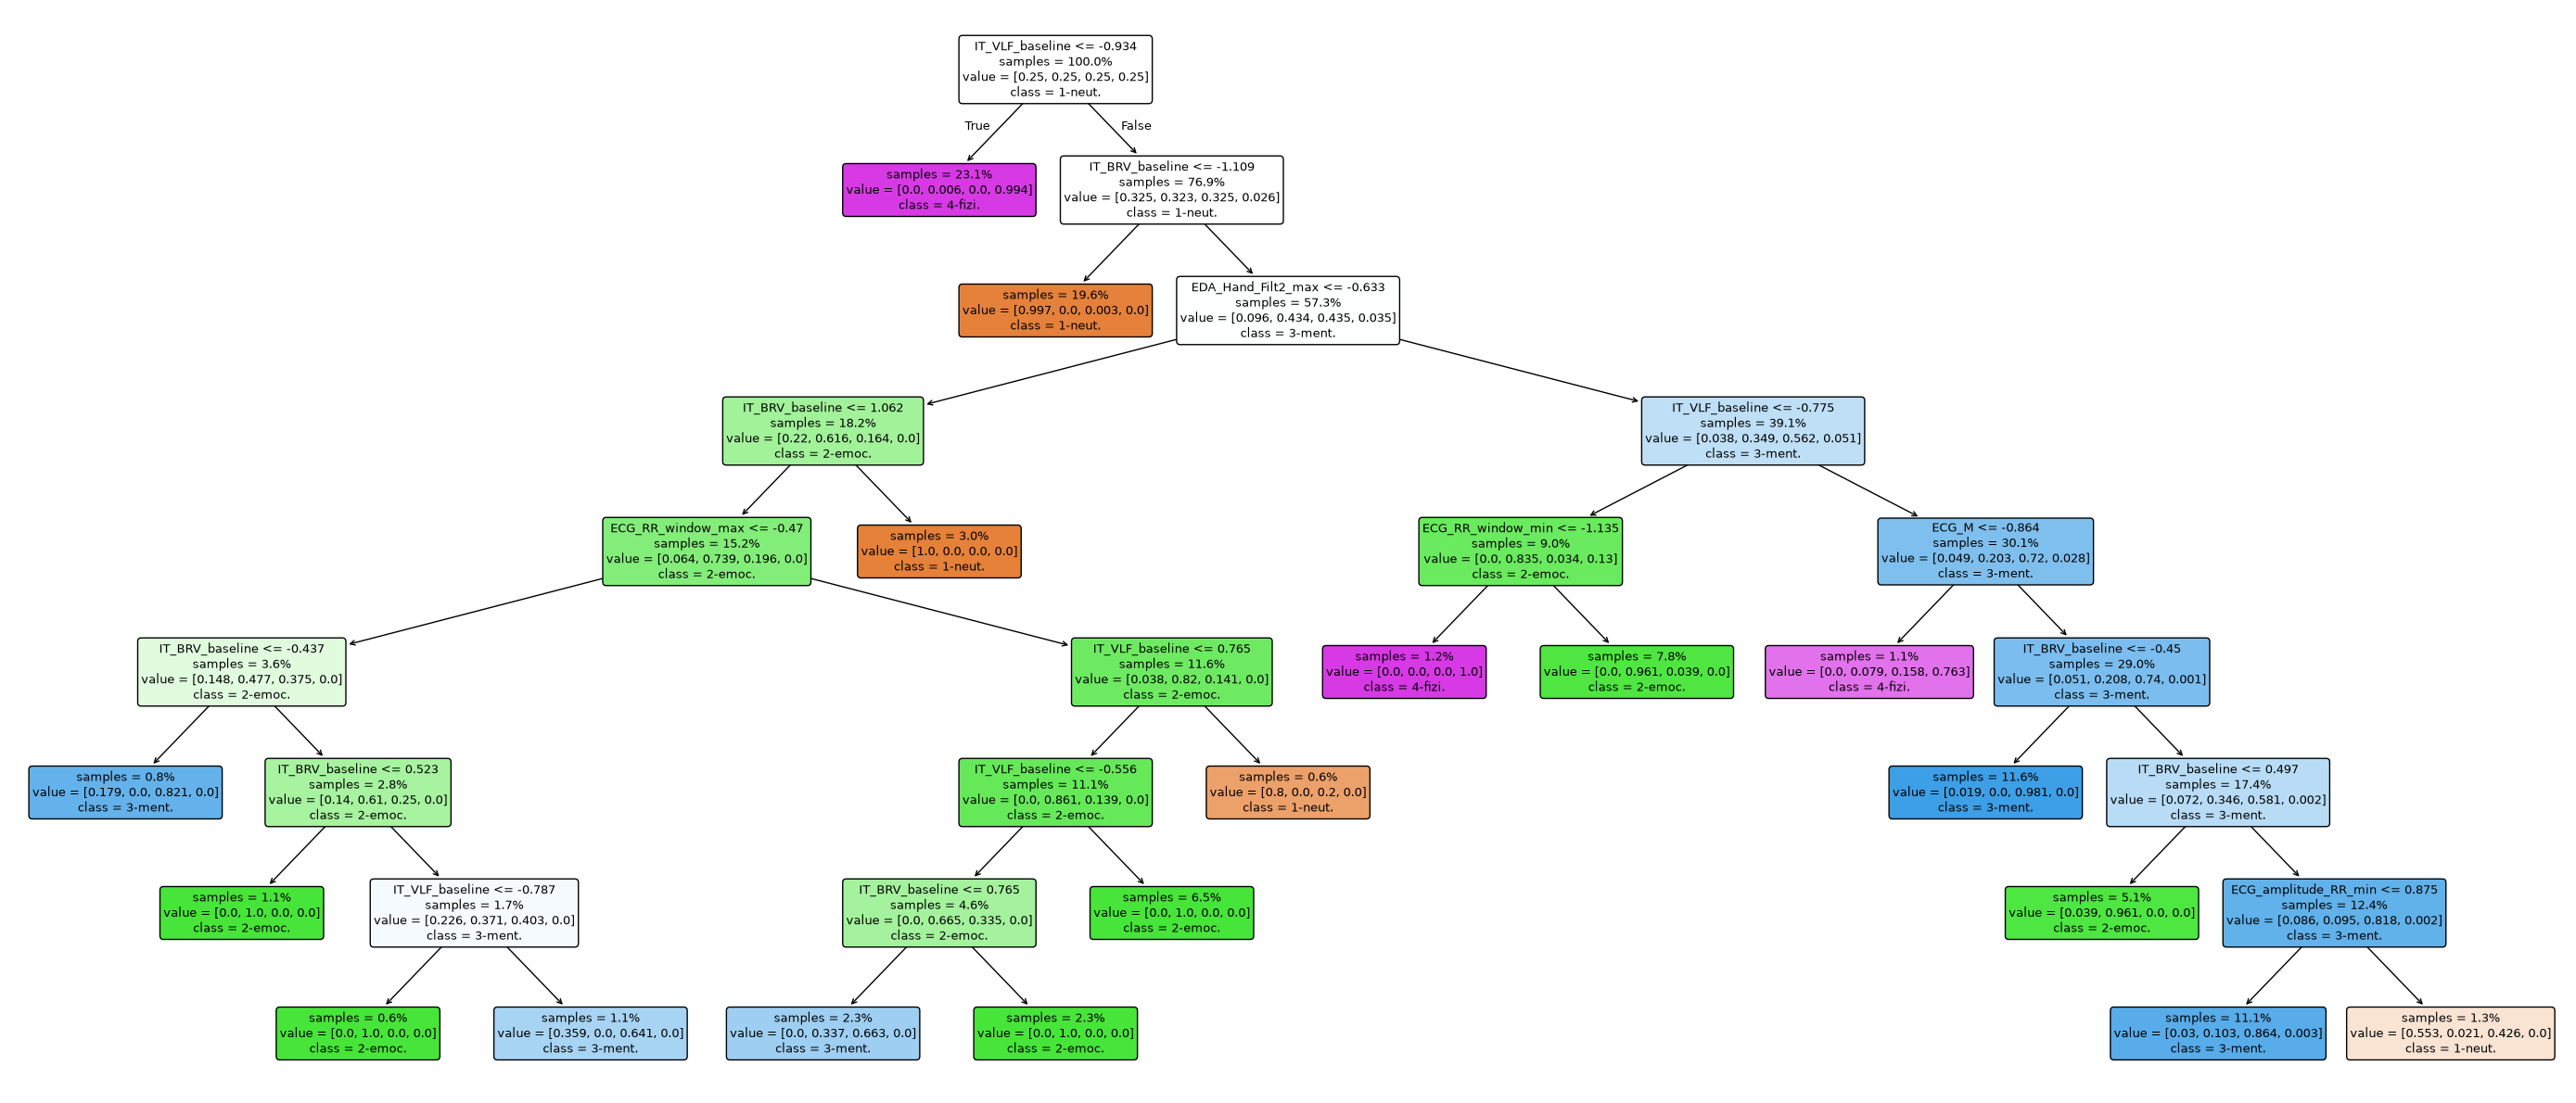

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names = list(
    dtc_feature_reduction_gs.best_estimator_
    .named_steps['feature_reduction'].get_feature_names_out()
)
class_names = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]

fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,          # boja = dominantna klasa, zasićenost = čistoća
    rounded=True,
    proportion=True,      # udeli umesto apsolutnih brojeva — čitljivije
    impurity=False,       # Gini vrednosti samo zatrpavaju čvorove
    fontsize=9,
    ax=ax,
)
plt.tight_layout()
# plt.savefig("dtc_interpretable_tree.png", dpi=200, bbox_inches="tight")
plt.show()

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

mem.clear(warn=False)

dct_pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.9, random_state=RANDOM_STATE)),
    ("decision_tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=None)),
], memory=mem)

param_grid = {
    "decision_tree__criterion": ["gini", "entropy"],
    "decision_tree__max_depth": [2, 3, 4, 5, 6, 8, 10],
    "decision_tree__min_samples_leaf": [1, 5, 10, 20, 40],
    "decision_tree__ccp_alpha": [0.0, 0.001, 0.003, 0.01],
    "decision_tree__max_features": ["sqrt", None, 0.5],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
dtc_pca_gs = GridSearchCV(dct_pca_pipeline, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
dtc_pca_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za DecisionTree nad PCA redukovanom skupu atributa: ")
print(" najbolji parametri: ", dtc_pca_gs.best_params_)
print(" broj PCA komponenti: ", dtc_pca_gs.best_estimator_.named_steps["pca"].n_components_)
print(" ukupna objasnjenja varijansa: ", dtc_pca_gs.best_estimator_.named_steps["pca"].explained_variance_ratio_.sum())
print(" najbolja tacnost na unakrsnoj validaciji: ", dtc_pca_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", dtc_pca_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, dtc_pca_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, dtc_pca_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 840 candidates, totalling 3360 fits
GridSearch za DecisionTree nad intepretabilnom, redukovanom skupu atributa: 
 najbolji parametri:  {'decision_tree__ccp_alpha': 0.01, 'decision_tree__criterion': 'gini', 'decision_tree__max_depth': 8, 'decision_tree__max_features': 0.5, 'decision_tree__min_samples_leaf': 20}
 broj PCA komponenti:  44
 ukupna objasnjenja varijansa:  0.9004374857767707
 najbolja tacnost na unakrsnoj validaciji:  0.759765625
 tacnost finalnog modela na test skupu:  0.7087053571428571
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      189       16       15        4
2-emoc.        7      176       33        8
3-ment.       22      125       72        5
4-fizi.       10        2       14      198
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.83      0.84      0.84       224
           2       0.55      0.79      0.65       224
           3       0.54     

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

mem.clear(warn=False)

dct_lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA(solver="svd", n_components=3)),
    ("decision_tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=None)),
], memory=mem)

#nema smisla koristiti max_features, jer imam samo 3 atributa
param_grid = {
    "decision_tree__criterion": ["gini", "entropy"],
    "decision_tree__max_depth": [2, 3, 4, 5, 6, 8, 10],
    "decision_tree__min_samples_leaf": [1, 5, 10, 20, 40],
    "decision_tree__ccp_alpha": [0.0, 0.001, 0.003, 0.01],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
dtc_lda_gs = GridSearchCV(dct_lda_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
dtc_lda_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za DecisionTree nad LDA komponentama:")
print(" najbolji parametri: ", dtc_lda_gs.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", dtc_lda_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", dtc_lda_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, dtc_lda_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, dtc_lda_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 280 candidates, totalling 1120 fits
GridSearchCV za KNN nad LDA komponentama:
 najbolji parametri:  {'decision_tree__ccp_alpha': 0.0, 'decision_tree__criterion': 'gini', 'decision_tree__max_depth': 5, 'decision_tree__min_samples_leaf': 10}
 najbolja tacnost na unakrsnoj validaciji:  0.7603236607142857
 tacnost finalnog modela na test skupu:  0.765625
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      164       11       49        0
2-emoc.        0      117      107        0
3-ment.        0       40      184        0
4-fizi.        0        0        3      221
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.73      0.85       224
           2       0.70      0.52      0.60       224
           3       0.54      0.82      0.65       224
           4       1.00      0.99      0.99       224

    accuracy                           0.77       896
   macro avg     